## Methodology

### Models and Training

Four architectures are trained independently on 15,000 CIFAR-10 samples using identical SGD hyperparameters ($\eta=0.1$, $\mu=0.9$, weight decay $10^{-4}$, batch size 128, cosine annealing, 15 epochs): **ResNet-20** (~272k parameters, 3 residual blocks per stage), **ResNet-8** (~78k, 1 block per stage), **TinyCNN** (~141k, plain convolutional without skip connections), and **SmallMLP** (~202k, fully connected, no inductive bias). After every mini-batch update the full parameter vector $\theta_t \in \mathbb{R}^{|\theta|}$ is stored in float16, yielding a trajectory $\{\theta_t\}_{t=1}^{T}$ with $T \approx 1{,}760$ iterates per model.

### Graph Construction

For each model the pairwise Euclidean distance matrix over all iterates is computed and fed into average-linkage hierarchical clustering. The threshold $\varepsilon$ is found by binary search to yield $K = 30$ clusters. Each cluster becomes a node in a directed quotient graph, with edge weights recording the number of consecutive iterate transitions between clusters. Nodes are relabelled chronologically by mean iterate index. The same pipeline is applied to all four models, enabling direct structural comparison.

### Cross-Architecture Comparison

The central question is whether qualitative graph structure is preserved across architectures differing in depth, skip connections, and inductive bias. Two properties are examined: (i) **linearity** — whether the quotient graph forms a near-linear chain rather than a branching or recurrent structure, regardless of model type; and (ii) **node size distribution** — whether the chronological pattern of small early nodes and large late nodes, indicative of convergence into a broad flat basin, is consistently reproduced. Systematic agreement across ResNet-20, ResNet-8, TinyCNN, and SmallMLP would suggest that these structural features reflect a property of SGD dynamics on CIFAR-10 rather than a model-specific artefact.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Subset
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.stats import spearmanr, linregress
import networkx as nx

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

EPOCHS       = 15
BATCH_SIZE   = 128
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4
TRAIN_SIZE   = 15000
TEST_SIZE    = 5000
DEVICE       = "mps" if torch.backends.mps.is_available() else "cpu"

TARGET_NODES     = 30
TARGET_NODES_SUB = 15
TOP_K_SUB        = 3
PERC_LOW         = 0
PERC_HIGH        = 100
MSD_MAX_TAU      = 30

print(f"Seed={SEED}  Device={DEVICE}")
print(f"Epochs={EPOCHS}  BS={BATCH_SIZE}  LR={LR}  "
      f"Mom={MOMENTUM}  WD={WEIGHT_DECAY}")
print(f"Train={TRAIN_SIZE}  Test={TEST_SIZE}")
print(f"Graph: N={TARGET_NODES}  Sub-N={TARGET_NODES_SUB}  "
      f"TopK={TOP_K_SUB}  MSD_MAX_TAU={MSD_MAX_TAU}")

Seed=42  Device=mps
Epochs=15  BS=128  LR=0.1  Mom=0.9  WD=0.0001
Train=15000  Test=5000
Graph: N=30  Sub-N=15  TopK=3  MSD_MAX_TAU=30


In [2]:
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3,
                                  stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3,
                                  stride=1, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_ch)
        self.relu     = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_ch))

    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        return self.relu(out + self.shortcut(x))


class ResNet20(nn.Module):
    """~272k Parameter."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 16, 3, stride=1,
                                  padding=1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = self._make_layer(16, 16, 3, stride=1)
        self.layer2  = self._make_layer(16, 32, 3, stride=2)
        self.layer3  = self._make_layer(32, 64, 3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(64, num_classes)

    def _make_layer(self, in_ch, out_ch, n, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(1, n):
            layers.append(BasicBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(self.avgpool(x).flatten(1))


class ResNet8(nn.Module):
    """~78k Parameter. 1 Block pro Stage."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 16, 3, stride=1,
                                  padding=1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = self._make_layer(16, 16, 1, stride=1)
        self.layer2  = self._make_layer(16, 32, 1, stride=2)
        self.layer3  = self._make_layer(32, 64, 1, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(64, num_classes)

    def _make_layer(self, in_ch, out_ch, n, stride):
        layers = [BasicBlock(in_ch, out_ch, stride)]
        for _ in range(1, n):
            layers.append(BasicBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x)
        return self.fc(self.avgpool(x).flatten(1))


class TinyCNN(nn.Module):
    """~141k Parameter. Kein Skip-Connection."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        return self.fc(self.features(x).flatten(1))


class SmallMLP(nn.Module):
    """~200k Parameter. Kein induktiver Bias."""
    def __init__(self, hidden=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3072, hidden),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


MODELS = {
    'ResNet20': ResNet20().to(DEVICE),
    'ResNet8':  ResNet8().to(DEVICE),
    'TinyCNN':  TinyCNN().to(DEVICE),
    'SmallMLP': SmallMLP(hidden=64).to(DEVICE),
}

print(f"{'Modell':<12} {'Parameter':>12}  {'RAM/It (f16)':>14}")
print("-" * 42)
for name, m in MODELS.items():
    n = sum(p.numel() for p in m.parameters())
    print(f"{name:<12} {n:>12,}  {n*2/1e6:>12.3f} MB")

Modell          Parameter    RAM/It (f16)
------------------------------------------
ResNet20          272,474         0.545 MB
ResNet8            78,042         0.156 MB
TinyCNN           141,034         0.282 MB
SmallMLP          201,738         0.403 MB


In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

trainset = Subset(
    torchvision.datasets.CIFAR10(
        './data', train=True, download=True,
        transform=transform_train),
    range(TRAIN_SIZE))
testset  = Subset(
    torchvision.datasets.CIFAR10(
        './data', train=False, download=True,
        transform=transform_test),
    range(TEST_SIZE))

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE,
    shuffle=True,  num_workers=0)
testloader  = torch.utils.data.DataLoader(
    testset,  batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0)

print(f"Train: {len(trainset)}  |  Test: {len(testset)}")

Files already downloaded and verified
Files already downloaded and verified
Train: 15000  |  Test: 5000


In [4]:
def train_model(model, name, trainloader, testloader,
                epochs, lr, momentum, weight_decay):
    torch.manual_seed(SEED)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr,
                          momentum=momentum,
                          weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs)

    train_losses, train_accs, test_accs = [], [], []
    iterates = []

    def snap():
        return np.concatenate([
            p.detach().cpu().numpy().ravel()
            for p in model.parameters()
        ]).astype(np.float16)

    for epoch in range(1, epochs + 1):
        model.train()
        rl, correct, total = 0.0, 0, 0

        for x, y in trainloader:
            x, y    = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(x)
            loss    = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            # Save every: nach jedem Batch
            iterates.append(snap())

            rl += loss.item() * x.size(0)
            with torch.no_grad():
                correct += outputs.max(1)[1].eq(y).sum().item()
            total += x.size(0)

        tl  = rl / total
        ta  = 100. * correct / total
        model.eval()
        c2, t2 = 0, 0
        with torch.no_grad():
            for x, y in testloader:
                x, y  = x.to(DEVICE), y.to(DEVICE)
                c2   += model(x).max(1)[1].eq(y).sum().item()
                t2   += y.size(0)
        tea = 100. * c2 / t2

        train_losses.append(tl)
        train_accs.append(ta)
        test_accs.append(tea)
        scheduler.step()
        print(f"  [{name}] Ep {epoch:2d}/{epochs}  "
              f"Loss={tl:.4f}  Train={ta:.1f}%  "
              f"Test={tea:.1f}%  Iters={len(iterates)}")

    return dict(
        iterates     = np.stack(iterates).astype(np.float32),
        train_losses = train_losses,
        train_accs   = train_accs,
        test_accs    = test_accs,
        n_params     = sum(p.numel() for p in model.parameters()))


RESULTS = {}
for name, model in MODELS.items():
    print(f"\n=== {name} ===")
    RESULTS[name] = train_model(
        model, name, trainloader, testloader,
        EPOCHS, LR, MOMENTUM, WEIGHT_DECAY)

print("\n── Zusammenfassung ──")
for name, r in RESULTS.items():
    print(f"  {name:<12}  Test={r['test_accs'][-1]:.1f}%  "
          f"Params={r['n_params']:,}  "
          f"Iterates={len(r['iterates'])}")


=== ResNet20 ===
  [ResNet20] Ep  1/15  Loss=1.9257  Train=27.6%  Test=22.9%  Iters=118
  [ResNet20] Ep  2/15  Loss=1.6521  Train=37.0%  Test=35.6%  Iters=236
  [ResNet20] Ep  3/15  Loss=1.4634  Train=45.7%  Test=43.8%  Iters=354
  [ResNet20] Ep  4/15  Loss=1.3096  Train=52.2%  Test=53.1%  Iters=472
  [ResNet20] Ep  5/15  Loss=1.1627  Train=58.1%  Test=57.2%  Iters=590
  [ResNet20] Ep  6/15  Loss=1.0660  Train=61.4%  Test=55.5%  Iters=708
  [ResNet20] Ep  7/15  Loss=0.9881  Train=64.4%  Test=62.2%  Iters=826
  [ResNet20] Ep  8/15  Loss=0.8940  Train=68.0%  Test=65.1%  Iters=944
  [ResNet20] Ep  9/15  Loss=0.8327  Train=70.1%  Test=65.0%  Iters=1062
  [ResNet20] Ep 10/15  Loss=0.7627  Train=72.9%  Test=70.9%  Iters=1180
  [ResNet20] Ep 11/15  Loss=0.7041  Train=75.0%  Test=71.5%  Iters=1298
  [ResNet20] Ep 12/15  Loss=0.6611  Train=76.1%  Test=73.5%  Iters=1416
  [ResNet20] Ep 13/15  Loss=0.6140  Train=78.2%  Test=75.2%  Iters=1534
  [ResNet20] Ep 14/15  Loss=0.5886  Train=79.4%  Test=

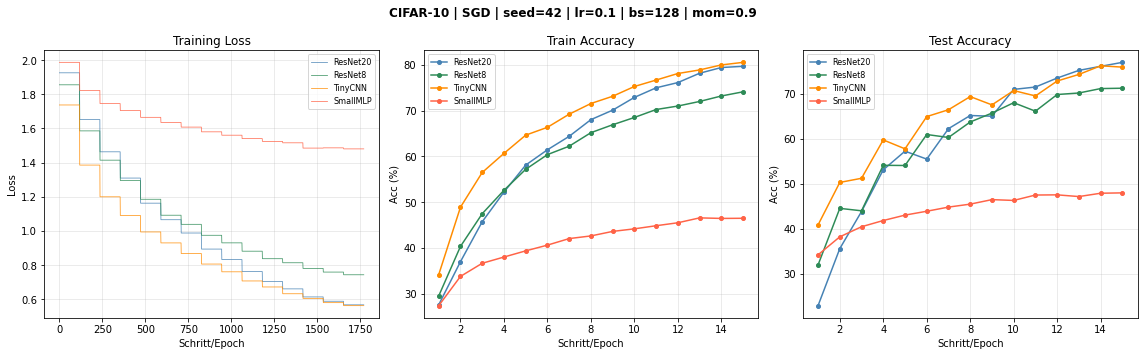

In [5]:
MODEL_COLORS = {
    'ResNet20': 'steelblue',
    'ResNet8':  'seagreen',
    'TinyCNN':  'darkorange',
    'SmallMLP': 'tomato',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for name, r in RESULTS.items():
    T     = len(r['iterates'])
    ep_of = [min(int(t/T*EPOCHS), EPOCHS-1) for t in range(T)]
    c     = MODEL_COLORS[name]
    axes[0].plot(range(T),
                 [r['train_losses'][e] for e in ep_of],
                 color=c, lw=0.8, alpha=0.85, label=name)
    axes[1].plot(range(1, EPOCHS+1), r['train_accs'],
                 'o-', color=c, lw=1.5, ms=4, label=name)
    axes[2].plot(range(1, EPOCHS+1), r['test_accs'],
                 'o-', color=c, lw=1.5, ms=4, label=name)

for ax, title, ylabel in [
        (axes[0], 'Training Loss',  'Loss'),
        (axes[1], 'Train Accuracy', 'Acc (%)'),
        (axes[2], 'Test Accuracy',  'Acc (%)')]:
    ax.set(title=title, xlabel='Schritt/Epoch', ylabel=ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f'CIFAR-10 | SGD | seed={SEED} | '
             f'lr={LR} | bs={BATCH_SIZE} | mom={MOMENTUM}',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [6]:
GRAPH_DATA = {}

for name, r in RESULTS.items():
    iters = r['iterates']
    T     = len(iters)
    i_lo  = int(np.percentile(np.arange(T), PERC_LOW))
    i_hi  = int(np.percentile(np.arange(T), PERC_HIGH))
    sel   = iters[i_lo:i_hi]
    T_sel = len(sel)

    print(f"\n── {name}  T_sel={T_sel}  D={sel.shape[1]:,} ──")
    print("  Berechne Distanzmatrix ...")
    dv = pdist(sel, metric='euclidean')
    dm = squareform(dv)
    print(f"  min={dv.min():.4f}  med={np.median(dv):.4f}  "
          f"max={dv.max():.4f}  "
          f"std/mean={dv.std()/dv.mean():.4f}")

    GRAPH_DATA[name] = dict(
        sel=sel, dv=dv, dm=dm, T_sel=T_sel)

print("\nAlle Distanzmatrizen fertig.")


── ResNet20  T_sel=1769  D=272,474 ──
  Berechne Distanzmatrix ...
  min=0.0065  med=8.7987  max=23.4232  std/mean=0.6380

── ResNet8  T_sel=1769  D=78,042 ──
  Berechne Distanzmatrix ...
  min=0.0052  med=7.2695  max=21.4166  std/mean=0.6916

── TinyCNN  T_sel=1769  D=141,034 ──
  Berechne Distanzmatrix ...
  min=0.0053  med=7.3799  max=22.6817  std/mean=0.6932

── SmallMLP  T_sel=1769  D=201,738 ──
  Berechne Distanzmatrix ...
  min=0.0039  med=5.9296  max=17.1536  std/mean=0.6416

Alle Distanzmatrizen fertig.


In [7]:
def do_clustering(dv, target, label=''):
    Z       = linkage(dv, method='average')
    N_S     = 250
    z_min   = Z[:,2].min()
    z_max   = Z[:,2].max()
    eps_min = max(z_min * 0.5, 1e-10)
    eps_max = z_max * 1.05
    if eps_min >= eps_max:
        eps_min = eps_max * 1e-4
    eps_arr = np.geomspace(eps_min, eps_max, N_S)
    nc_arr  = np.array([
        fcluster(Z, t=e, criterion='distance').max()
        for e in eps_arr])
    idx_t     = int(np.argmax(nc_arr <= target))
    eps_t     = eps_arr[idx_t]
    labels_c  = fcluster(Z, t=eps_t,
                          criterion='distance') - 1
    idx_first = int(np.argmax(nc_arr < len(dv)))
    idx_perc  = int(np.argmax(
        -np.diff(nc_arr.astype(float)))) + 1
    idx_conn  = int(np.argmax(nc_arr == 1))
    print(f"  {label}: ε={eps_t:.5f}  "
          f"N={labels_c.max()+1}")
    return dict(Z=Z, labels=labels_c, eps=eps_t,
                eps_arr=eps_arr, nc_arr=nc_arr,
                idx_first=idx_first,
                idx_perc=idx_perc,
                idx_conn=idx_conn)

for name in RESULTS:
    d = GRAPH_DATA[name]
    print(f"\n── {name} ──")
    d['cl'] = do_clustering(d['dv'], TARGET_NODES, name)


── ResNet20 ──
  ResNet20: ε=2.24897  N=30

── ResNet8 ──
  ResNet8: ε=1.90141  N=28

── TinyCNN ──
  TinyCNN: ε=1.84794  N=30

── SmallMLP ──
  SmallMLP: ε=1.99780  N=29


In [9]:
def build_graph(iters, labels, label=''):
    n = labels.max() + 1
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for t in range(len(labels) - 1):
        u, v = int(labels[t]), int(labels[t+1])
        if G.has_edge(u, v): G[u][v]['weight'] += 1
        else:                G.add_edge(u, v, weight=1)
    for nid in range(n):
        times = np.where(labels == nid)[0]
        G.nodes[nid]['size']      = len(times)
        G.nodes[nid]['mean_time'] = (float(np.mean(times))
                                     if len(times) else 0.)
        G.nodes[nid]['times']     = times
        G.nodes[nid]['centroid']  = (iters[times].mean(0)
                                     if len(times)
                                     else np.zeros(
                                         iters.shape[1]))
    ns = sum(1 for u, v in G.edges if u == v)
    print(f"  {label}: {n} Knoten | "
          f"{G.number_of_edges()} Kanten | "
          f"{ns} Selbstschleifen")
    return G


for name in RESULTS:
    d = GRAPH_DATA[name]
    print(f"\n── {name} ──")
    d['G'] = build_graph(
        d['sel'], d['cl']['labels'], name)


── ResNet20 ──
  ResNet20: 30 Knoten | 59 Kanten | 30 Selbstschleifen

── ResNet8 ──
  ResNet8: 28 Knoten | 55 Kanten | 28 Selbstschleifen

── TinyCNN ──
  TinyCNN: 30 Knoten | 59 Kanten | 30 Selbstschleifen

── SmallMLP ──
  SmallMLP: 29 Knoten | 57 Kanten | 29 Selbstschleifen


In [26]:
from scipy.interpolate import make_interp_spline
from matplotlib.colors import Normalize
import matplotlib.patheffects as pe

def plot_graph_chain(G, ax,
                     title=None,
                     show_title=True,
                     nodes_per_row=8,
                     col_spacing=3.0,
                     row_spacing=4.2,
                     min_radius=0.150,
                     max_radius=1.10,
                     size_exponent=1.0,
                     global_min_size=None,
                     global_max_size=None,
                     corner_bulge=0.7,
                     cmap_name='coolwarm',
                     path_color='#c8c8c8',
                     path_lw=5,
                     fs_title=13,
                     fs_tick=9,
                     fs_node=11,
                     fs_cbar=10,
                     title_pad=22):
    n = G.number_of_nodes()
    if n == 0:
        ax.text(.5, .5, 'Empty graph', ha='center', va='center',
                transform=ax.transAxes)
        return

    # ── Sort nodes chronologically by mean_time ───────────────────────────────
    nodes_sorted = sorted(G.nodes, key=lambda nd: G.nodes[nd]['mean_time'])

    sizes   = np.array([G.nodes[nd]['size'] for nd in nodes_sorted], dtype=float)
    ref_min = float(global_min_size) if global_min_size is not None else sizes.min()
    ref_max = float(global_max_size) if global_max_size is not None else sizes.max()
    t_sz    = np.clip((sizes - ref_min) / max(ref_max - ref_min, 1e-9), 0., 1.)
    radii   = min_radius + (max_radius - min_radius) * t_sz ** size_exponent

    # ── Snake positions (0 = earliest, n-1 = latest) ─────────────────────────
    pos   = np.zeros((n, 2))
    x_max = (nodes_per_row - 1) * col_spacing
    for i in range(n):
        row = i // nodes_per_row
        col = i %  nodes_per_row
        if row % 2 == 1:
            col = nodes_per_row - 1 - col
        pos[i] = [col * col_spacing, -row * row_spacing]

    # ── Colours: blue (early) → red (late) ───────────────────────────────────
    cmap_obj = plt.get_cmap(cmap_name)
    colors   = [cmap_obj(i / max(n - 1, 1)) for i in range(n)]

    # ── Spline path with rounded corner waypoints ─────────────────────────────
    px, py = [pos[0, 0]], [pos[0, 1]]
    for i in range(1, n):
        if (i // nodes_per_row) != ((i - 1) // nodes_per_row):
            x0, y0 = pos[i - 1]
            y_mid  = (y0 + pos[i, 1]) / 2
            bulge  = x0 + corner_bulge if x0 > x_max / 2 else x0 - corner_bulge
            px.append(bulge); py.append(y_mid)
        px.append(pos[i, 0]); py.append(pos[i, 1])

    px, py = np.array(px, dtype=float), np.array(py, dtype=float)
    diffs  = np.hypot(np.diff(px), np.diff(py))
    t_pts  = np.concatenate([[0.], np.cumsum(diffs)]); t_pts /= t_pts[-1]
    t_fine = np.linspace(0., 1., len(px) * 80)
    k      = min(3, len(px) - 1)

    ax.plot(make_interp_spline(t_pts, px, k=k)(t_fine),
            make_interp_spline(t_pts, py, k=k)(t_fine),
            color=path_color, lw=path_lw,
            solid_capstyle='round', solid_joinstyle='round', zorder=1)

    # ── Nodes & labels ────────────────────────────────────────────────────────
    for i in range(n):
        ax.add_patch(plt.Circle(pos[i], radii[i], color=colors[i],
                                zorder=3, linewidth=1.2, edgecolor='white'))
        ax.text(pos[i, 0], pos[i, 1] + radii[i] + 0.15,
                str(int(sizes[i])),
                ha='center', va='bottom',
                fontsize=fs_node,
                color='#111111', zorder=5,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

    # ── Colourbar ─────────────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap_name, norm=Normalize(0, 1))
    sm.set_array([])
    cb = plt.colorbar(sm, ax=ax, orientation='vertical',
                      fraction=0.018, pad=0.03, shrink=0.55)
    cb.set_label('Training progress', fontsize=fs_cbar)
    cb.set_ticks([0., 1.]); cb.set_ticklabels(['Early', 'Late'])
    cb.ax.tick_params(labelsize=fs_tick)

    ax.set_aspect('equal')
    pad_x = col_spacing * 0.7 + corner_bulge + 0.3
    pad_y = row_spacing * 0.55
    ax.set_xlim(pos[:, 0].min() - pad_x, pos[:, 0].max() + pad_x)
    ax.set_ylim(pos[:, 1].min() - pad_y, pos[:, 1].max() + pad_y + 0.5)
    ax.set_axis_off()

    if show_title and title:
        ax.set_title(title, fontsize=fs_title, pad=title_pad)

print("plot_graph_chain defined.")

plot_graph_chain defined.


/var/folders/98/qqtppv95393dnyk73t3r03dh0000gn/T/ipykernel_86816/2024522060.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Circle(pos[i], radii[i], color=colors[i],
/var/folders/98/qqtppv95393dnyk73t3r03dh0000gn/T/ipykernel_86816/2024522060.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Circle(pos[i], radii[i], color=colors[i],
/var/folders/98/qqtppv95393dnyk73t3r03dh0000gn/T/ipykernel_86816/2024522060.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Circle(pos[i], radii[i], color=colors[i],
/var/folders/98/qqtppv95393dnyk73t3r03dh0000gn/T/ipykernel_86816/2024522060.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Circle(pos[i], radii[i], color=colors[i],


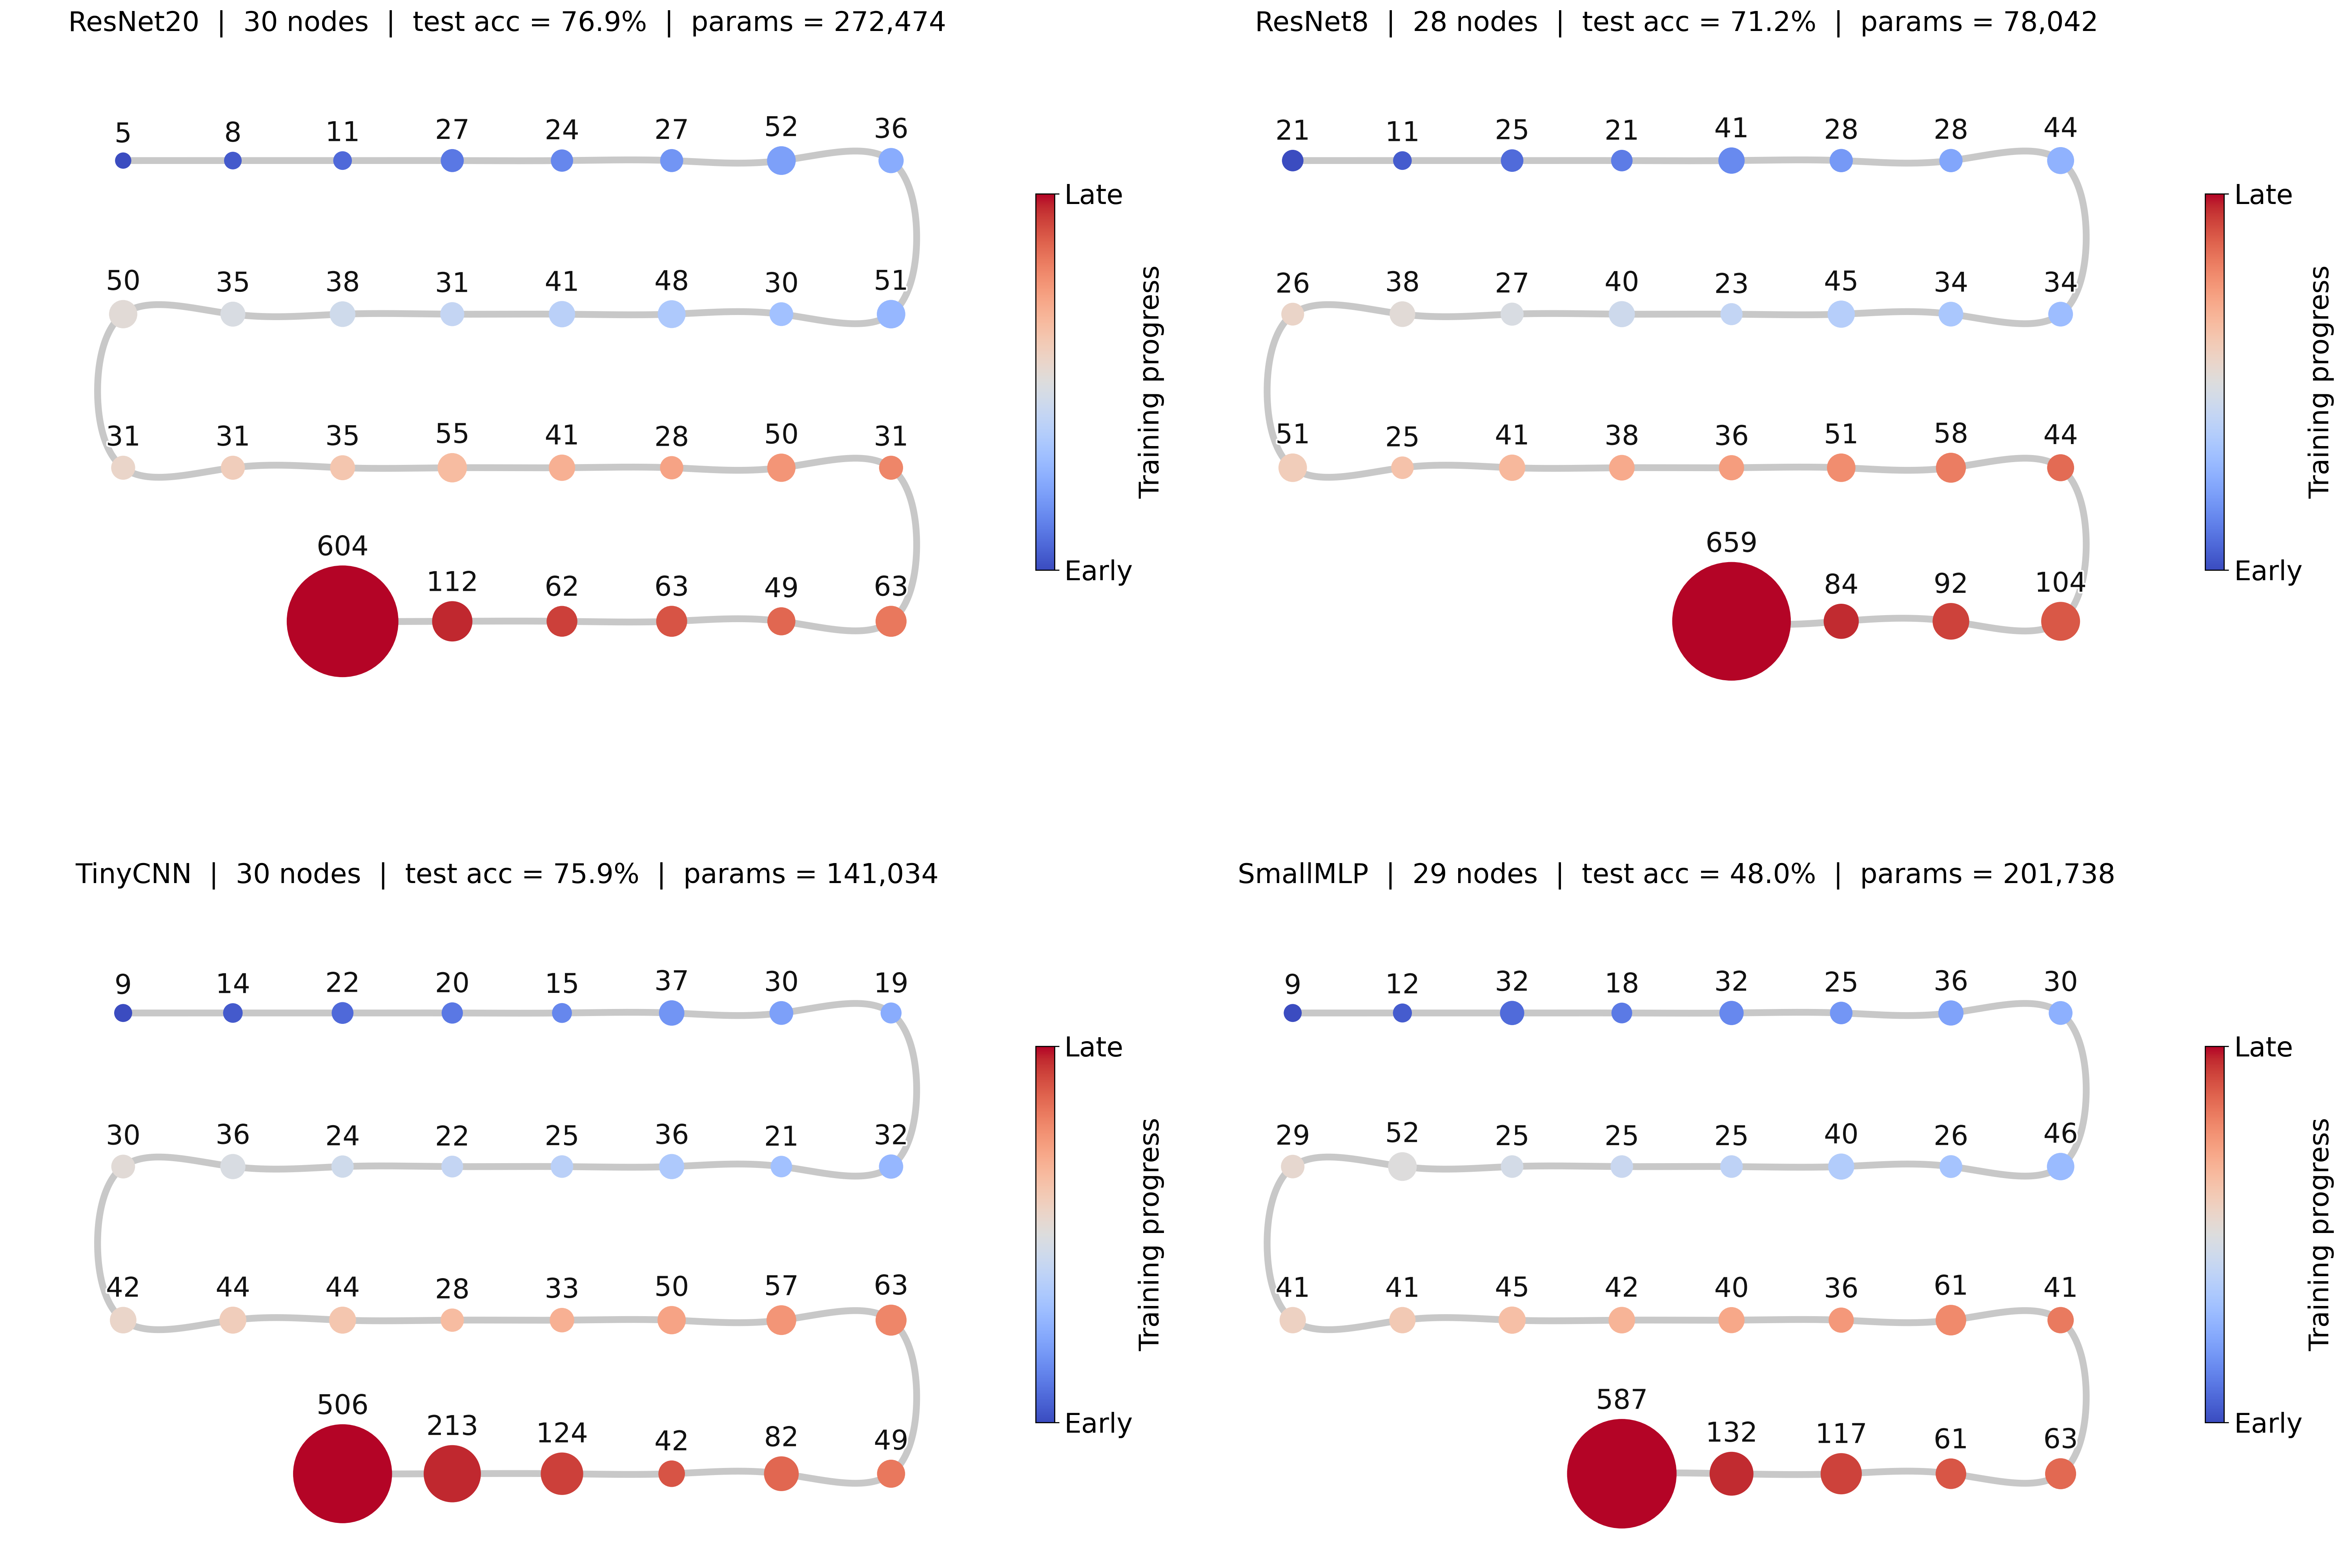

In [33]:
all_sizes_all = np.concatenate([
    [GRAPH_DATA[name]['G'].nodes[i]['size']
     for i in GRAPH_DATA[name]['G'].nodes]
    for name in RESULTS])
GLOBAL_MIN_ALL = float(all_sizes_all.min())
GLOBAL_MAX_ALL = float(all_sizes_all.max())

FS_TITLE = 20
FS_TICK  = 20
FS_NODE  = 20
FS_CBAR  = 20

n_models = len(RESULTS)
ncols    = 2
nrows    = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 12, nrows * 9),
                          dpi=250)
axes_flat = axes.ravel() if n_models > 1 else [axes]

for ax, name in zip(axes_flat, RESULTS):
    d = GRAPH_DATA[name]
    r = RESULTS[name]
    G = d['G']

    sub_title = (f"{name}  |  {G.number_of_nodes()} nodes  |  "
                 f"test acc = {r['test_accs'][-1]:.1f}%  |  "
                 f"params = {r['n_params']:,}")

    plot_graph_chain(
        G, ax,
        title=sub_title,
        show_title=True,
        nodes_per_row=8,
        col_spacing=3.0,
        row_spacing=4.2,
        min_radius=0.20,
        max_radius=1.60,
        size_exponent=0.8,
        global_min_size=GLOBAL_MIN_ALL,
        global_max_size=GLOBAL_MAX_ALL,
        corner_bulge=0.7,
        path_lw=5,
        fs_title=FS_TITLE,
        fs_tick=FS_TICK,
        fs_node=FS_NODE,
        fs_cbar=FS_CBAR,
        title_pad=20)

for ax in axes_flat[n_models:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


── ResNet20 ──
  ResNet20: τ_mean=2.5418  τ_med=2.4172  n=30

── ResNet8 ──
  ResNet8: τ_mean=2.8298  τ_med=2.5677  n=28

── TinyCNN ──
  TinyCNN: τ_mean=2.7008  τ_med=2.3502  n=30

── SmallMLP ──
  SmallMLP: τ_mean=2.2688  τ_med=2.0607  n=29


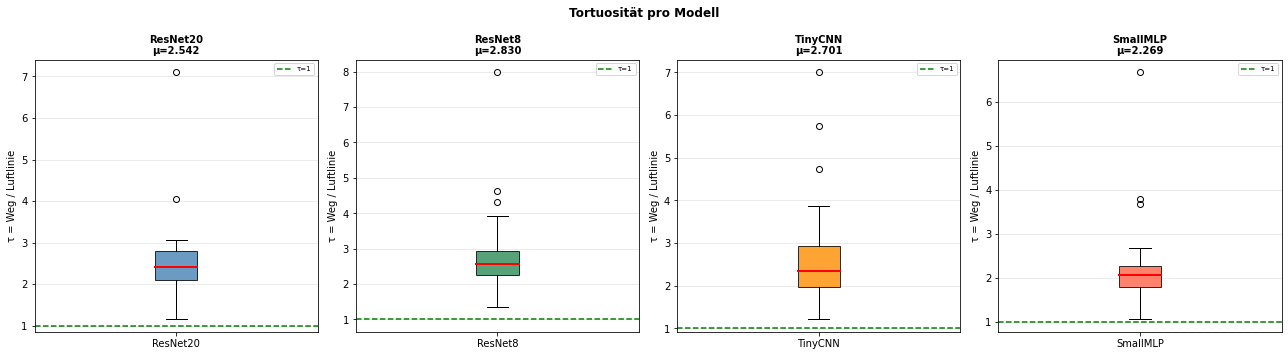

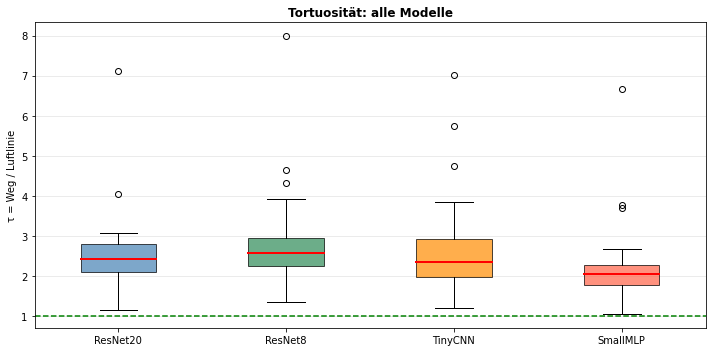

In [11]:
def compute_tortuosity(G, dm, label=''):
    res = {}
    for nid in G.nodes:
        times = np.sort(G.nodes[nid]['times'])
        if len(times) < 2:
            res[nid] = []; continue
        runs, run = [], [times[0]]
        for i in range(1, len(times)):
            if times[i] - times[i-1] == 1:
                run.append(times[i])
            else:
                if len(run) >= 2:
                    runs.append(np.array(run))
                run = [times[i]]
        if len(run) >= 2:
            runs.append(np.array(run))
        tl = []
        for r in runs:
            pl = sum(dm[r[i], r[i+1]]
                     for i in range(len(r)-1))
            di = dm[r[0], r[-1]]
            if di > 1e-10:
                tl.append(pl / di)
        res[nid] = tl
    flat = [t for lst in res.values() for t in lst]
    if flat:
        print(f"  {label}: τ_mean={np.mean(flat):.4f}  "
              f"τ_med={np.median(flat):.4f}  "
              f"n={len(flat)}")
    return res, flat


for name in RESULTS:
    d = GRAPH_DATA[name]
    print(f"\n── {name} ──")
    d['tort'], d['flat_tort'] = compute_tortuosity(
        d['G'], d['dm'], name)

# Boxplot pro Modell
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, name in zip(axes, RESULTS):
    d  = GRAPH_DATA[name]
    c  = MODEL_COLORS[name]
    if not d['flat_tort']:
        ax.set_visible(False); continue
    bp = ax.boxplot(
        [d['flat_tort']], labels=[name],
        patch_artist=True,
        medianprops=dict(color='red', lw=2))
    bp['boxes'][0].set_facecolor(c)
    bp['boxes'][0].set_alpha(0.8)
    ax.axhline(1.0, color='green', ls='--',
               lw=1.5, label='τ=1')
    mu = np.mean(d['flat_tort'])
    ax.set_title(f'{name}\nμ={mu:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('τ = Weg / Luftlinie')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Tortuosität pro Modell',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Alle Modelle im Vergleich
fig, ax = plt.subplots(figsize=(10, 5))
data = [GRAPH_DATA[n]['flat_tort']
        for n in RESULTS if GRAPH_DATA[n]['flat_tort']]
labs = [n for n in RESULTS
        if GRAPH_DATA[n]['flat_tort']]
cols = [MODEL_COLORS[n] for n in labs]
bp   = ax.boxplot(data, labels=labs,
                   patch_artist=True,
                   medianprops=dict(color='red', lw=2))
for patch, c in zip(bp['boxes'], cols):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.axhline(1.0, color='green', ls='--', lw=1.5)
ax.set_ylabel('τ = Weg / Luftlinie')
ax.set_title('Tortuosität: alle Modelle',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

ResNet20: ρ=0.7102  p=1.10e-05  Gini=0.4740
ResNet8: ρ=0.7452  p=5.38e-06  Gini=0.4962
TinyCNN: ρ=0.8719  p=3.53e-10  Gini=0.5117
SmallMLP: ρ=0.8055  p=1.36e-07  Gini=0.4885


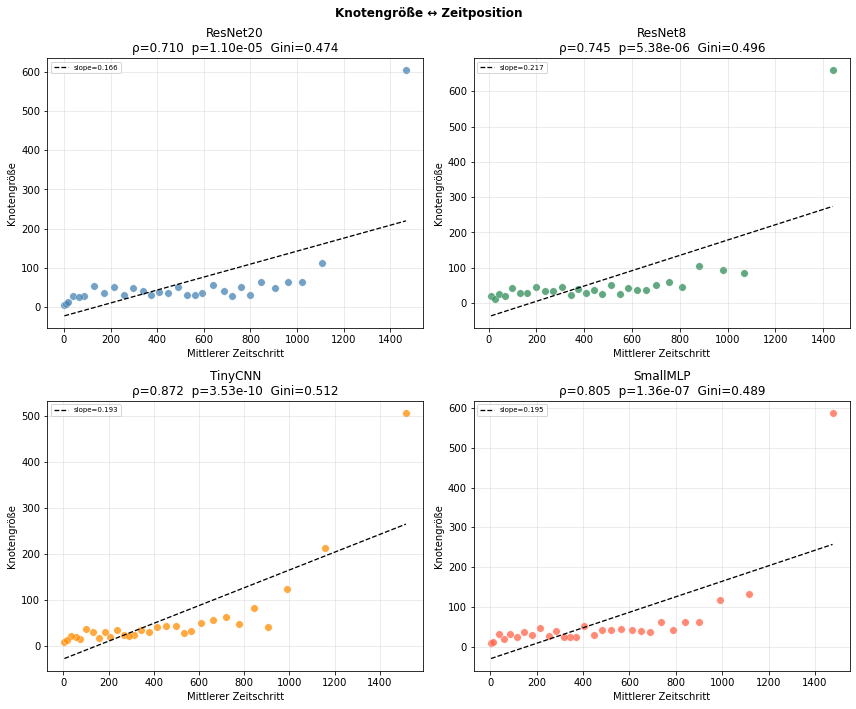

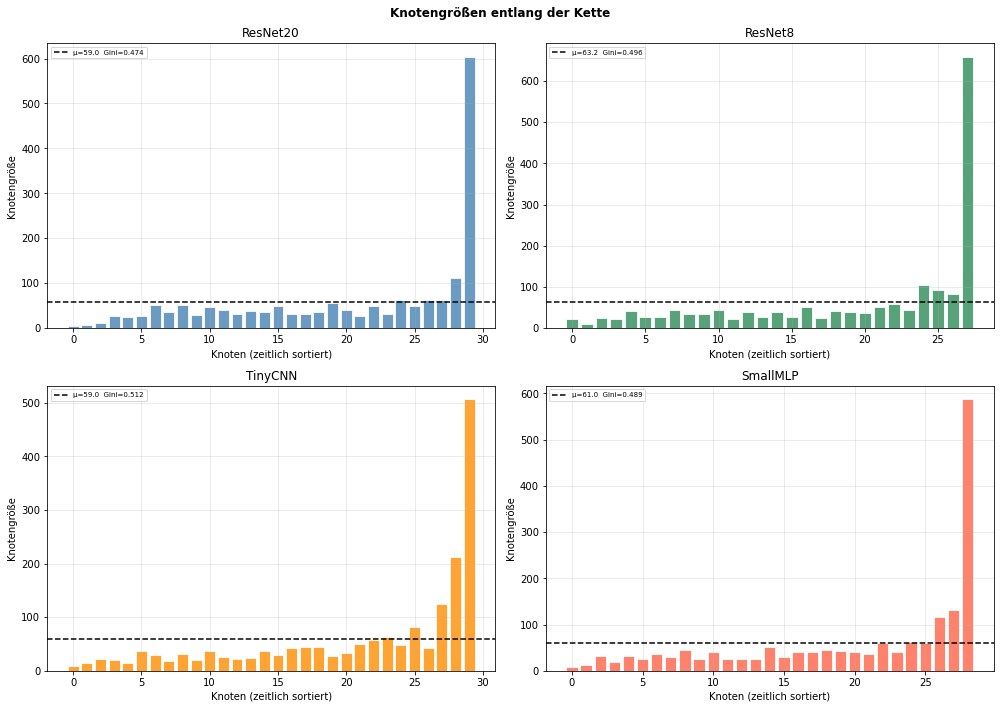

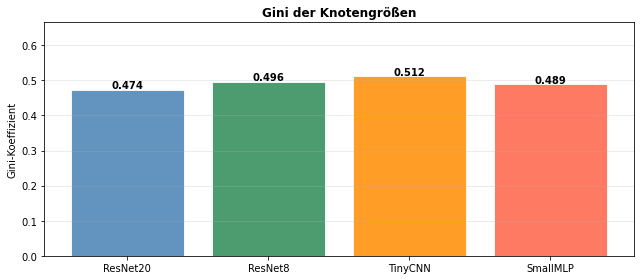

In [12]:
def gini_coeff(sizes):
    s = np.sort(sizes); n = len(s)
    return (2*np.sum(s*np.arange(1, n+1)) /
            (n*np.sum(s))) - (n+1)/n


SUMMARY = {}
for name in RESULTS:
    d     = GRAPH_DATA[name]
    G     = d['G']
    sizes = np.array([G.nodes[n]['size']
                      for n in G.nodes])
    times = np.array([G.nodes[n]['mean_time']
                      for n in G.nodes])
    r, p  = spearmanr(times, sizes)
    g     = gini_coeff(sizes)
    SUMMARY[name] = dict(sizes=sizes, times=times,
                          r=r, p=p, gini=g)
    print(f"{name}: ρ={r:.4f}  p={p:.2e}  Gini={g:.4f}")

# Scatter
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, name in zip(axes.ravel(), RESULTS):
    e = SUMMARY[name]; c = MODEL_COLORS[name]
    ax.scatter(e['times'], e['sizes'],
               color=c, alpha=0.75, s=55,
               edgecolors='white', lw=0.4)
    z  = np.polyfit(e['times'], e['sizes'], 1)
    tl = np.linspace(e['times'].min(),
                     e['times'].max(), 100)
    ax.plot(tl, np.polyval(z, tl), 'k--', lw=1.3,
            label=f'slope={z[0]:.3f}')
    ax.set(xlabel='Mittlerer Zeitschritt',
           ylabel='Knotengröße',
           title=f'{name}\n'
                 f'ρ={e["r"]:.3f}  p={e["p"]:.2e}  '
                 f'Gini={e["gini"]:.3f}')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle('Knotengröße ↔ Zeitposition',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Balken entlang Kette
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, name in zip(axes.ravel(), RESULTS):
    e   = SUMMARY[name]; c = MODEL_COLORS[name]
    ord = np.argsort(e['times'])
    sz  = e['sizes'][ord]
    ax.bar(range(len(sz)), sz, color=c,
           alpha=0.8, edgecolor='white')
    ax.axhline(np.mean(sz), color='black',
               ls='--', lw=1.5,
               label=f'μ={np.mean(sz):.1f}  '
                     f'Gini={e["gini"]:.3f}')
    ax.set(xlabel='Knoten (zeitlich sortiert)',
           ylabel='Knotengröße', title=name)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle('Knotengrößen entlang der Kette',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Gini Balkendiagramm
fig, ax = plt.subplots(figsize=(9, 4))
names  = list(RESULTS.keys())
ginis  = [SUMMARY[n]['gini'] for n in names]
cols   = [MODEL_COLORS[n]    for n in names]
bars   = ax.bar(names, ginis, color=cols,
                alpha=0.85, edgecolor='white')
for bar, val in zip(bars, ginis):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.3f}', ha='center',
            fontsize=10, fontweight='bold')
ax.set_ylabel('Gini-Koeffizient')
ax.set_title('Gini der Knotengrößen',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(ginis)*1.3)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()